# K-Nearest Neighbors (KNN) — Iris Flower Classification

## About this project
This notebook explores the **K-Nearest Neighbors (KNN)** supervised machine learning algorithm applied to the classic **Iris dataset**. The goal is to build a classifier capable of predicting the species of an iris flower based on its physical measurements.

KNN is a simple, non-parametric algorithm that classifies a new data point by looking at the **k closest points** in the training set and assigning the majority class. Despite its simplicity, it can achieve excellent results when the data is well-scaled and the features carry discriminative information.

## Dataset
The Iris dataset contains **150 samples** across **3 species** (*Setosa*, *Versicolor*, *Virginica*), each described by 4 numerical features:
- `sepal_length` — length of the sepal (cm)
- `sepal_width`  — width of the sepal (cm)
- `petal_length` — length of the petal (cm)
- `petal_width`  — width of the petal (cm)

## Notebook Structure
| # | Section | Description |
|---|---------|-------------|
| 1 | Libraries | Import all required packages |
| 2 | Data Extraction | Load and preview the dataset |
| 3 | EDA | Explore distributions, class balance, and feature relationships |
| 4 | Model Building | Build and tune the KNN classifier using pipelines and grid search |
| 5 | Evaluation | Measure model performance with multiple classification metrics |

---
## 1. Libraries

We import the core libraries for data manipulation, visualization, modeling, and evaluation:

- **pandas / numpy** — data handling and numerical operations
- **matplotlib / seaborn** — static visualizations
- **scikit-learn** — ML pipeline: preprocessing, model, tuning, and metrics
- **scipy.stats** — statistical utilities (normality tests, skewness, kurtosis)

In [1]:
# --- Data manipulation and numerical computing ---
import pandas as pd
import numpy as np

# --- Visualization ---
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# --- Scikit-learn: model, preprocessing, pipeline, and tuning ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline


# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Global plot style
PALETTE = "Set2"
sns.set(style="whitegrid", font_scale=1.05)

---
## 2. Data Extraction

We load the Iris dataset from a local CSV file using `pandas`. A random sample of 5 rows is displayed to confirm the structure and that the data loaded correctly.

> **Dataset:** 150 rows × 5 columns — 4 numeric features + 1 categorical target (`species`).

In [2]:
# Load the dataset from CSV — comma separated
data = pd.read_csv("iris_dataset.csv", sep=",")

# Preview 5 random rows to confirm successful loading
data.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
69,5.6,2.5,3.9,1.1,versicolor
117,7.7,3.8,6.7,2.2,virginica
43,5.0,3.5,1.6,0.6,setosa
136,6.3,3.4,5.6,2.4,virginica
38,4.4,3.0,1.3,0.2,setosa


---
## 3. Exploratory Data Analysis (EDA)

Before training any model, we must understand the data. This section covers:

1. **Overview** — shape, data types, null values, and basic statistics per column
2. **Class balance** — check whether the target classes are evenly distributed
3. **Feature distributions** — understand the spread and shape of each numerical feature
4. **Pairplot** — visualize pairwise relationships and class separability across features

> This step is critical for detecting problems early (missing values, heavy imbalance, overlapping classes) and for deciding preprocessing strategies.

### 3.0 Data Overview

In [3]:
def df_info(df):
    """Returns a consolidated summary table combining describe() stats with dtype, null, and uniqueness info."""

    # Standard descriptive statistics (count, mean, std, min, max, percentiles)
    desc = df.describe().round(2)

    # Build a supplementary row-based summary for each column
    extra_metrics = pd.DataFrame({
        "dtype":    df.dtypes,                                          # column data type
        "nulls":    df.isnull().sum(),                                  # absolute null count
        "% nulls":  (df.isnull().sum() / len(df) * 100).round(2),      # null percentage
        "unique":   df.nunique(),                                       # number of unique values
        "example":  df.iloc[0],                                         # first row as example value
    }).T

    # Merge both tables into a single view
    final_df = pd.concat([desc, extra_metrics])

    print(f"the dataframe shape is {df.shape[0]} rows X {df.shape[1]} columns")
    return final_df

In [4]:
df_info(data)

the dataframe shape is 150 rows X 5 columns


,sepal_length,sepal_width,petal_length,petal_width,species
count,150.0,150.0,150.0,150.0,NaN
mean,5.84,3.06,3.76,1.2,NaN
std,0.83,0.44,1.77,0.76,NaN
min,4.3,2.0,1.0,0.1,NaN
25%,5.1,2.8,1.6,0.3,NaN
50%,5.8,3.0,4.35,1.3,NaN
75%,6.4,3.3,5.1,1.8,NaN
max,7.9,4.4,6.9,2.5,NaN
dtype,float64,float64,float64,float64,str
nulls,0,0,0,0,0


### 3.1 Class Balance — Target Distribution

A balanced dataset means each class has roughly the same number of samples. This matters for KNN because a heavily imbalanced dataset would bias the majority-vote prediction toward the dominant class.

> A **ratio ≤ 2:1** is generally considered acceptable for KNN without requiring resampling techniques.

In [5]:
def plot_target(df: pd.DataFrame, target: str) -> None:
    """
    Visualizes the class distribution of the target column using a bar chart and a pie chart.
    Also prints a class imbalance warning if the max/min ratio exceeds 2.
    """
    # Count occurrences and compute percentages per class
    counts = df[target].value_counts()
    pcts   = df[target].value_counts(normalize=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"'{target}' Distribution", fontsize=14, fontweight="bold")

    # --- Bar chart: absolute counts ---
    sns.barplot(x=counts.index.astype(str), y=counts.values,
                palette=PALETTE, ax=axes[0])
    axes[0].set_title("Clases Count")
    axes[0].set_xlabel(target)
    axes[0].set_ylabel("Count")

    # Annotate each bar with its count value
    for bar, val in zip(axes[0].patches, counts.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5, str(val),
                     ha="center", va="bottom", fontweight="bold")

    # --- Pie chart: proportions ---
    axes[1].pie(pcts.values, labels=counts.index.astype(str),
                autopct="%1.1f%%", colors=sns.color_palette(PALETTE, len(counts)),
                startangle=90)
    axes[1].set_title("Proportion by class")

    plt.tight_layout()
    plt.show()

    # Warn if classes are significantly imbalanced (ratio > 2:1)
    ratio = counts.max() / counts.min()
    if ratio > 2:
        print(f"Imbalance Detected (ratio {ratio:.1f}:1). "
              "Considering SMOTE, class_weight o subsampling.")
    else:
        print(f"Reasonably balanced classes (ratio {ratio:.1f}:1).")

C:\Users\Dilan Calvo\AppData\Local\Temp\ipykernel_23224\1278658202.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values,


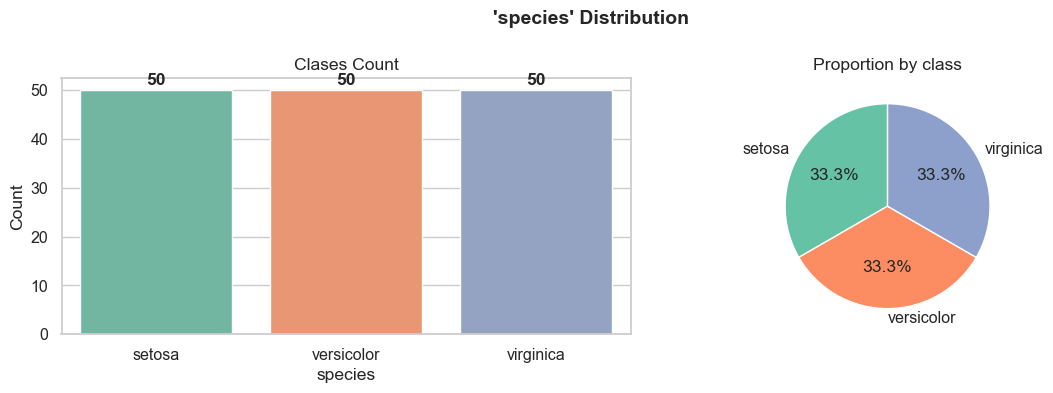

Reasonably balanced classes (ratio 1.0:1).


In [6]:
plot_target(data, "species")

### 3.2 Feature Distributions

Understanding the distribution of each feature helps us detect skewness, outliers, and whether normalization is needed.

For KNN specifically, **feature scaling is essential** — the algorithm measures distances between points, so features with larger scales dominate the distance calculation. We use `StandardScaler` later in the pipeline to address this.

Each histogram is overlaid per class to also reveal how well each feature separates the species.

In [7]:
def plot_distributions(df: pd.DataFrame, target: str = None, cols: int = 4) -> None:
    """
    Plot distributions of numerical features in the DataFrame.
    If a target column is provided, distributions are overlaid per class.

    Parameters:
    - df     : Input DataFrame
    - target : Optional target column for per-class overlays
    - cols   : Number of columns in the subplot grid
    """
    # Select only numeric columns, excluding the target if provided
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    if target and target in numeric_cols:
        numeric_cols.remove(target)

    # Compute subplot grid dimensions
    rows = int(np.ceil(len(numeric_cols) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        if target:
            # Plot one histogram per class with transparency for overlap visibility
            for cls in df[target].unique():
                subset = df[df[target] == cls][col].dropna()
                axes[i].hist(subset, bins=30, alpha=0.5, label=str(cls), density=True)

            # Overlay the global distribution in blue for reference
            axes[i].hist(df[col].dropna(), bins=30, color="steelblue", alpha=0.75)

        axes[i].set_title(col, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Density")

    # Hide any unused subplot axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Distribution of Numerical Features", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

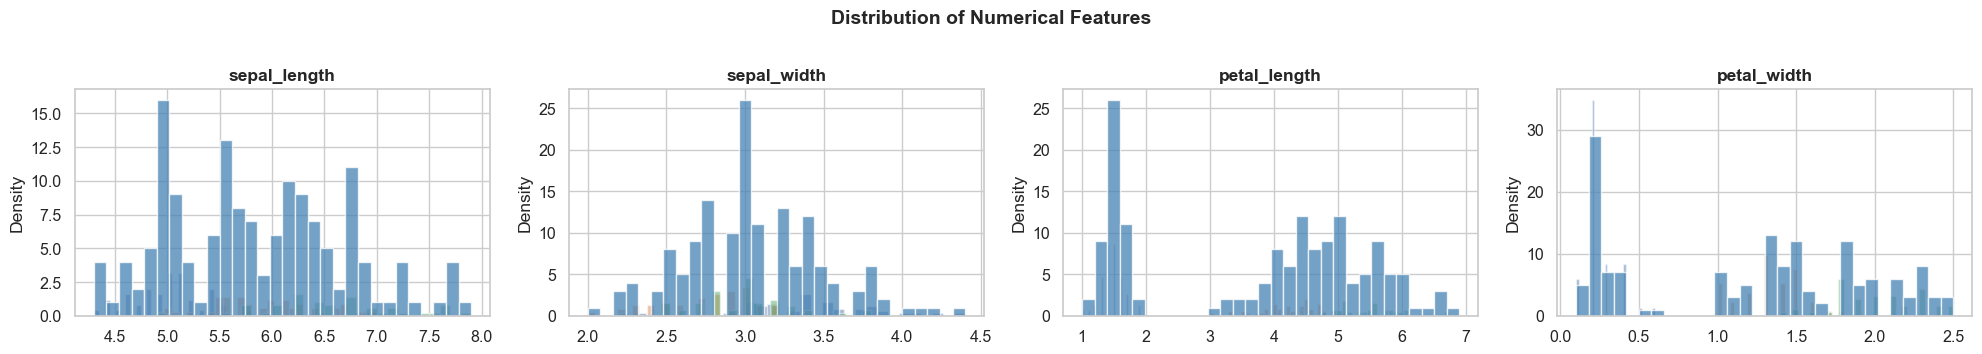

In [8]:
plot_distributions(data, "species")

### 3.3 Pairplot — Feature Relationships

A pairplot shows **scatter plots between every pair of features** and **KDE curves on the diagonal**, colored by species. This gives a holistic view of:

- **Class separability** — how clearly the species cluster in feature space
- **Linear vs. non-linear relationships** between features
- **Feature importance hints** — pairs where classes form distinct clusters are likely high-value predictors

The function automatically ranks features by their absolute correlation with the encoded target and selects the top ones (`max_features=6`).

In [9]:
def plot_pairplot(df: pd.DataFrame, target: str,
                  features: list = None, max_features: int = 6) -> None:
    """
    Generates a pairplot for the top correlated features against the target.

    Parameters:
    - df           : Input DataFrame
    - target       : Target column name used for coloring
    - features     : Explicit list of features to include (optional)
    - max_features : Max number of features to auto-select if 'features' is None
    """

    if features is None:
        # Select only numeric columns as candidate features
        numeric_df = df.select_dtypes(include="number").drop(columns=[target], errors="ignore")

        if pd.api.types.is_numeric_dtype(df[target]):
            # If target is numeric, correlate directly
            corrs = numeric_df.corrwith(df[target]).abs().sort_values(ascending=False)
        else:
            # If target is categorical, encode it first to enable correlation
            encoder = LabelEncoder()
            y_encoded = pd.Series(encoder.fit_transform(df[target]), index=df.index)
            corrs = numeric_df.corrwith(y_encoded).abs().sort_values(ascending=False)

        # Keep only the top N most correlated features
        features = corrs.head(max_features).index.tolist()

    # Build subset and drop rows with missing values
    subset = df[features + [target]].dropna()

    g = sns.pairplot(subset, hue=target, palette=PALETTE,
                     diag_kind="kde", plot_kws={"alpha": 0.6})

    g.fig.suptitle(f"Pairplot — top features vs '{target}'",
                   y=1.02, fontsize=14, fontweight="bold")
    plt.show()

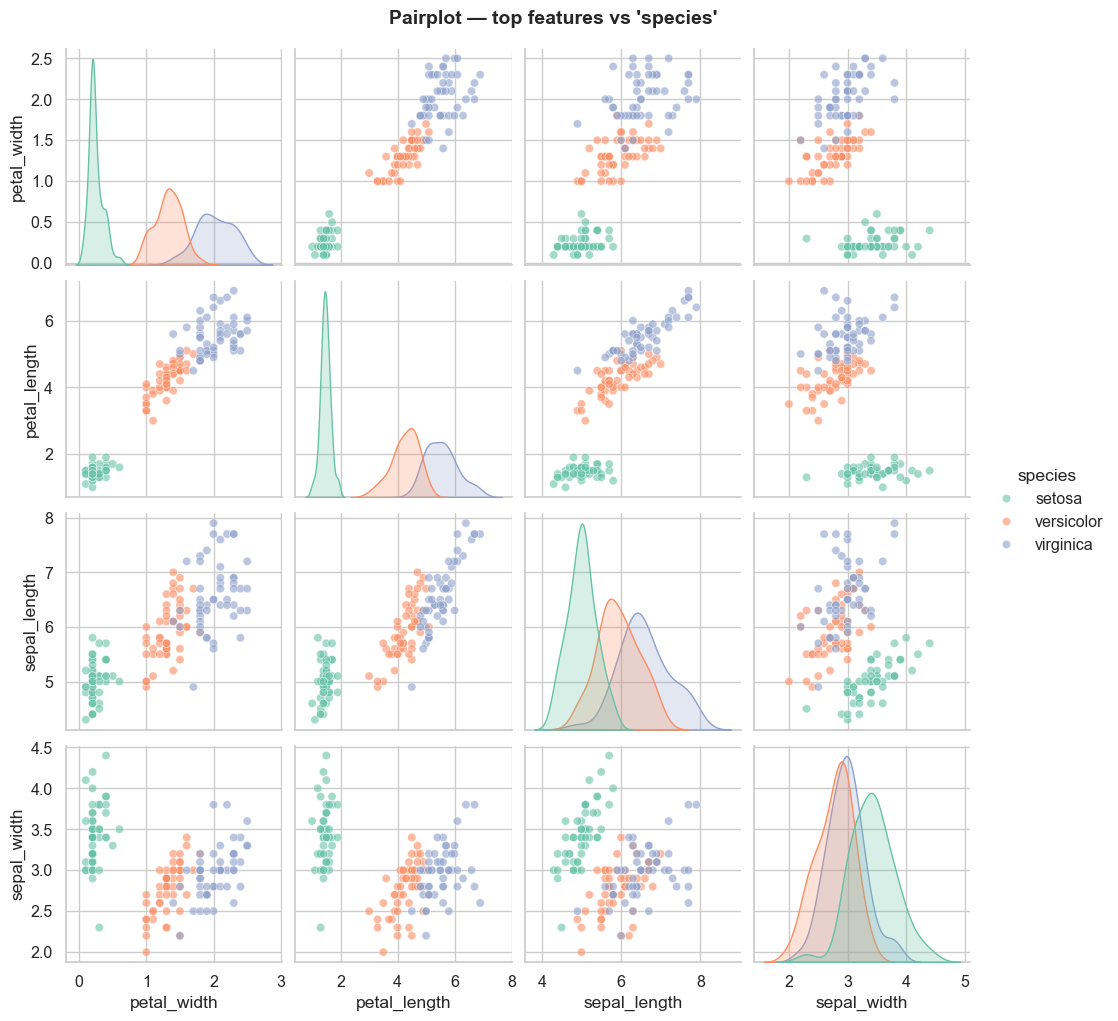

In [10]:
plot_pairplot(data, "species")

---
## 4. Model Building

With the EDA complete, we proceed to build our KNN classifier. This section is structured in three steps:

1. **Train / Test Split** — separate data into training and test sets
2. **Pipeline + Hyperparameter Grid** — define the preprocessing + model + search space
3. **Grid Search Training** — find the optimal hyperparameters via cross-validation

### 4.0 Train / Test Split

We split the data **70% training / 30% test** using `stratify=y` to ensure that the class proportions are preserved in both subsets. This is important to avoid a biased evaluation, especially for multi-class problems.

> `random_state=78012` ensures reproducibility of the split.

In [11]:
# Separate features (X) from the target variable (y)
X = data.drop(columns="species")
y = data["species"]

# Split into training and test sets
# - test_size=0.3  : 30% for testing, 70% for training
# - stratify=y     : preserve class proportions in both splits
# - random_state   : fix seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=78012
)

### 4.1 Pipeline & Hyperparameter Grid

We use a **scikit-learn Pipeline** to chain preprocessing and modeling into a single object. This design prevents **data leakage** — the scaler is fit only on the training fold during cross-validation, never on the validation or test data.

**Pipeline steps:**
| Step | Transformer | Purpose |
|------|------------|---------|
| `ss` | `StandardScaler` | Normalize features to mean=0, std=1 — required for distance-based algorithms like KNN |
| `knn` | `KNeighborsClassifier` | The classifier |

**Hyperparameter search space:**
| Parameter | Values | Description |
|-----------|--------|-------------|
| `n_neighbors` | 1, 3, 5, ..., 10 (odd) | Only odd values avoid ties in majority voting |
| `weights` | `uniform`, `distance` | `uniform` = all neighbors count equally; `distance` = closer neighbors have more influence |

We also configure a **10-fold StratifiedKFold** cross-validator to evaluate each combination while preserving class ratios in every fold.

In [12]:
# Define the processing pipeline: scale features → apply KNN
pipe = Pipeline([
    ("ss", StandardScaler()),       # Step 1: standardize features (mean=0, std=1)
    ("knn", KNeighborsClassifier()) # Step 2: KNN classifier
])

# Search space: only odd values for n_neighbors to avoid ties in voting
param_grid = {
    "knn__n_neighbors": [x for x in range(1, 11) if x % 2 != 0],
    "knn__weights":     ["uniform", "distance"]
}

# 10-fold stratified cross-validation — preserves class proportions across folds
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

### 4.2 Model Training — Grid Search

`GridSearchCV` exhaustively tries every combination in `param_grid`, evaluating each with 10-fold cross-validation and selecting the combination with the highest **weighted F1-score**.

- **Weighted F1** is used as the scoring metric because it accounts for class support (number of samples per class), making it robust for multi-class problems even if some imbalance exists.

In [13]:
model = GridSearchCV(pipe, param_grid, cv=skf, scoring='f1_weighted')

model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 3, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

---
## 5. Model Evaluation

We evaluate the best model found by GridSearchCV on the **held-out test set** (data the model has never seen). The evaluation covers:

| Metric | Description |
|--------|-------------|
| **Accuracy** | Fraction of correctly classified samples overall |
| **Precision** | Of all positive predictions, how many were truly positive (weighted avg.) |
| **Recall** | Of all actual positives, how many were correctly identified (weighted avg.) |
| **F1-Score** | Harmonic mean of Precision and Recall — balances both |
| **Confusion Matrix** | Table showing correct vs. incorrect predictions per class |

> **Note:** ROC curve is only generated for binary classification problems. Since Iris has 3 classes, it will not appear here.

In [14]:
def model_evaluation(modelo, X_test, y_test, nombres_clases=None):
    """
    Evaluates a fitted classification model on a test set.
    Prints key metrics, best hyperparameters (if GridSearchCV), classification report,
    and renders a confusion matrix heatmap. ROC curve is included for binary problems only.
    """

    # Generate predictions on the test set
    y_pred = modelo.predict(X_test)

    # --- Compute core metrics (weighted avg. for multi-class support) ---
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print("MODEL METRICS")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    # Print best hyperparameters if the model was tuned via GridSearchCV
    if hasattr(modelo, "best_params_"):
        print("\nBEST HYPERPARAMETERS")
        print("-" * 40)
        for k, v in modelo.best_params_.items():
            print(f"{k}: {v}")

    # Detailed per-class breakdown: precision, recall, f1, support
    print("\nCLASSIFICATION REPORT")
    print("-" * 40)
    print(classification_report(y_test, y_pred, target_names=nombres_clases))

    # --- Confusion Matrix ---
    # Rows = actual class, Columns = predicted class
    # Diagonal cells = correct predictions
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # --- ROC Curve (binary classification only) ---
    # Not applicable here since Iris has 3 classes
    if len(np.unique(y_test)) == 2 and hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier baseline
        plt.title("ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.show()

MODEL METRICS
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

BEST HYPERPARAMETERS
----------------------------------------
knn__n_neighbors: 7
knn__weights: uniform

CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



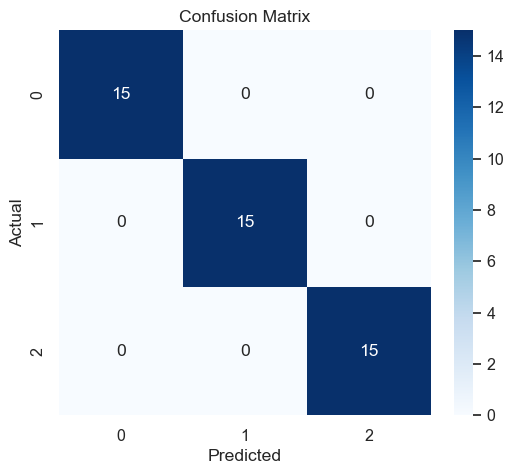

In [15]:
model_evaluation(model, X_test, y_test)

---
## 6. Conclusion

### How KNN works (in context)
K-Nearest Neighbors is one of the simplest supervised learning algorithms. Given a new unseen data point, it:
1. Computes the **distance** (typically Euclidean) between that point and **every training sample**
2. Selects the **k closest neighbors**
3. Assigns the **majority class** among those k neighbors as the prediction

There are no model parameters to learn — KNN is a **lazy learner** that memorizes the training set and defers computation to prediction time.

### Why KNN on Iris?
The Iris dataset is an ideal use case for KNN because:
- **Small and clean** — 150 samples, no missing values, no noise
- **Well-separated classes** — as seen in the pairplot, *Setosa* is linearly separable; *Versicolor* and *Virginica* overlap slightly but remain distinguishable
- **Low dimensionality** — only 4 features, so distance calculations remain meaningful (no curse of dimensionality)

### Key design decisions
| Decision | Rationale |
|----------|-----------|
| `StandardScaler` in pipeline | KNN is distance-based; features must be on the same scale |
| Odd values for `n_neighbors` | Avoids tied votes in multi-class prediction |
| `weights='distance'` option | Gives more influence to closer neighbors, can improve boundary accuracy |
| 10-fold `StratifiedKFold` | Robust estimate of generalization — each fold preserves class ratios |
| `f1_weighted` scoring | Appropriate for multi-class problems; accounts for class support |

### Final takeaway
This project demonstrates that even a simple, non-parametric algorithm like KNN — when properly scaled and tuned — can achieve **strong classification performance** on structured datasets. The combination of a clean pipeline, grid search, and stratified cross-validation ensures that the reported results are reliable and not the product of a lucky data split.